---
title: "Compressed sensing"
categories: []
---

Compressed sensing inverts the usual sampling logic. A conventional acquisition pipeline measures a signal $\mathbf{x}\in\mathbb{R}^n$ coordinate by coordinate, so the cost of acquisition scales with $n$. [Compressed sensing]{.mark} instead asks whether an $n$-dimensional signal can be recovered from only $m \ll n$ **linear measurements**

$$
\mathbf{b} = \mathbf{A}\mathbf{x}, \qquad \mathbf{A}\in\mathbb{R}^{m\times n},\quad m < n,
$$

taken through a measurement matrix $\mathbf{A}$ that is known in advance. As written, the problem is underdetermined: Chapter 8 showed that the least-squares solutions of such a system form an affine subspace, and Chapter 6 singled out the **minimum-norm solution** $\mathbf{x} = \mathbf{A}^{+}\mathbf{b}$ among them. That solution exists for every $\mathbf{A}$ and $\mathbf{b}$, but for a generic signal it is badly wrong, and the first experiment below makes the failure visible.

The twist that rescues the problem is **sparsity**: when $\mathbf{x}$ has only $K \ll n$ nonzero entries, exact recovery becomes possible, and the required number of measurements scales like

$$
m \sim K\log(n/K).
$$

The acquisition does not change — the same linear operator $\mathbf{A}$ is used — only the recovery rule changes, from $\mathbf{A}^{+}\mathbf{b}$ to a *minimum-$\ell_1$* solution.

The setting is not academic. A CT scanner estimates a tissue-density image from a few [line integrals]{.mark}: each X-ray projection is one linear measurement, and fewer projections means less radiation dose. MRI acquires Fourier samples of an image, and fewer samples means a shorter scan. Sensor networks, radar, and genomics face the same arithmetic: acquisition cost is set by the number of measurements, so a recovery theory that works with $m \ll n$ measurements is directly a theory of cheaper and faster acquisition. This chapter develops that theory in two steps: a one-dimensional experiment that isolates the geometry of sparsity, and a two-dimensional computed-tomography-style reconstruction that exercises the full pipeline.


In [1]:
from watchtower.core import set_format
set_format("svg")


## The counter-example: minimum-norm fails

**The setup.** A sparse signal $\mathbf{x}\in\mathbb{R}^{128}$ with $K = 5$ nonzero entries is measured through a random Gaussian matrix $\mathbf{A}\in\mathbb{R}^{40\times 128}$ with independent standard-normal entries, giving $\mathbf{b} = \mathbf{A}\mathbf{x}$. With $m = 40 < n = 128$ the system is underdetermined, and the canonical recovery from Chapters 6 and 8 is the minimum-norm solution $\hat{\mathbf{x}} = \mathbf{A}^{+}\mathbf{b}$, computed with `np.linalg.pinv`. The cell records how far that solution sits from the truth.


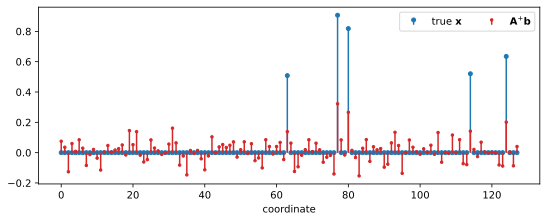

relative error ||x - A^+ b|| / ||x|| = 0.823
sqrt(1 - m/n) = 0.829
||A^+ b||^2 = 0.782,  (m/n)||x||^2 = 0.758


In [2]:
#| label: fig-minnorm
#| cap: "**Minimum-norm recovery of a sparse signal.** The true 5-sparse signal $\\mathbf{x}$ (blue) and the minimum-norm solution $\\mathbf{A}^{+}\\mathbf{b}$ (red). The reconstruction spreads energy over all 128 coordinates instead of concentrating it on the five nonzero ones."
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

n, m, K = 128, 40, 5
x = np.zeros(n)
x[rng.choice(n, size=K, replace=False)] = rng.uniform(0.5, 1.0, size=K)   # <1>
A = rng.standard_normal((m, n))
b = A @ x

x_pinv = np.linalg.pinv(A) @ b                                             # <2>

fig, ax = plt.subplots(figsize=(9, 3.2))
s1 = ax.stem(x, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='true $\\mathbf{x}$')
s1.markerline.set_markersize(4)
s2 = ax.stem(x_pinv, linefmt='C3-', markerfmt='C3o', basefmt=' ', label='$\\mathbf{A}^{+}\\mathbf{b}$')
s2.markerline.set_markersize(2.5)
ax.set_xlabel('coordinate')
ax.legend(ncol=2)
plt.show()

err_pinv = np.linalg.norm(x - x_pinv) / np.linalg.norm(x)
print(f'relative error ||x - A^+ b|| / ||x|| = {err_pinv:.3f}')
print(f'sqrt(1 - m/n) = {np.sqrt(1 - m / n):.3f}')
print(f'||A^+ b||^2 = {np.linalg.norm(x_pinv) ** 2:.3f},'
      f'  (m/n)||x||^2 = {m / n * np.linalg.norm(x) ** 2:.3f}')


**The minimum-norm solution spreads the energy.** The annotations: `<1>` selects the support — five coordinates at random, each with a uniform magnitude in $[0.5, 1]$; `<2>` computes the pseudoinverse solution. Two observations deserve comment.

First, the reconstruction is dense: every one of the 128 coordinates carries some mass, and the printed error is 0.82. This is forced. For a Gaussian $\mathbf{A}$ with $m < n$, the rows are independent with probability one, and then $\mathbf{A}^{+}\mathbf{A} = \mathbf{P}_{\mathsf{C}(\mathbf{A}^{\mathsf T})}$ is the orthogonal projection onto the $m$-dimensional row space (Chapter 6). The minimum-norm solution is therefore the projection of the true signal onto a *random* $m$-dimensional subspace,

$$
\hat{\mathbf{x}} = \mathbf{A}^{+}\mathbf{A}\mathbf{x} = \mathbf{P}_{\mathsf{C}(\mathbf{A}^{\mathsf T})}\mathbf{x},
$$

and a random subspace is aligned with no coordinate in particular: it keeps the expected fraction $m/n$ of the energy, so the relative error is $\sqrt{1 - m/n} = 0.829$, matching the printed 0.823 and the printed energy identity $\lVert\hat{\mathbf{x}}\rVert^2 \approx (m/n)\lVert\mathbf{x}\rVert^2$.

Second, the failure has nothing to do with noise — $\mathbf{b}$ is exact. It is the recovery rule that fails. The minimum-norm solution is the smallest-energy explanation of the measurements, and the true signal is the opposite of small-energy: it is *concentrated* on five coordinates. Minimizing energy and finding sparsity are different objectives, and the $\ell_2$ ball simply has no way to express the second one.


## L1 versus L2: the geometry of sparsity

The minimum-norm solution minimizes the $\ell_2$ norm over the feasible set $\{\mathbf{x} : \mathbf{A}\mathbf{x} = \mathbf{b}\}$: it is the point of that affine set closest to the origin. The failure above suggests minimizing a different measure of size. For any norm, the solution of $\min \lVert\mathbf{x}\rVert$ over an affine set is the point where the *smallest* norm ball around the origin touches the set, and the shape of the ball decides the outcome. The $\ell_1$ unit ball is the diamond with vertices on the coordinate axes — the same unit balls drawn in Chapter 1 — and an affine set touching the smallest $\ell_1$ ball generically touches it at a vertex, that is, at a point with some coordinates exactly zero. The $\ell_2$ ball has no vertices, so its touching point is generic: all coordinates nonzero. The figure below puts both balls against the same feasible line.


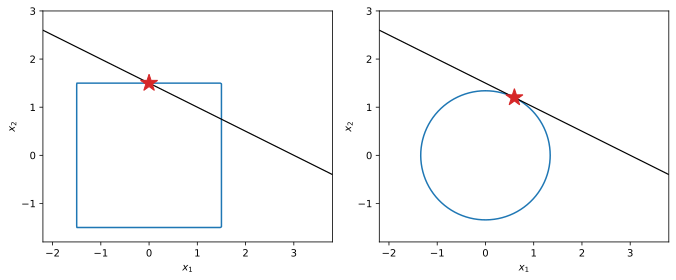

In [3]:
#| label: fig-l1l2-balls
#| cap: "**The corner is the sparse point.** The feasible line $x_1 + 2x_2 = 3$ with the smallest $\\ell_1$ ball (left) and the smallest $\\ell_2$ ball (right) that reach it. The $\\ell_1$ ball touches at the vertex $(0, 1.5)$ — a point with a zero coordinate — while the $\\ell_2$ ball touches tangentially at $(0.6, 1.2)$, where both coordinates are nonzero."
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2 * np.pi, 500)
rho = np.maximum(np.abs(np.cos(t)), np.abs(np.sin(t)))
r1, r2 = 1.5, 3 / np.sqrt(5)                    # smallest L1 radius; L2 radius
ball1 = r1 * np.c_[np.cos(t), np.sin(t)] / rho[:, None]
ball2 = r2 * np.c_[np.cos(t), np.sin(t)]

x1s = np.linspace(-2.2, 3.8, 200)               # feasible line: x1 + 2 x2 = 3
x2s = (3 - x1s) / 2

fig, ax = plt.subplots(1, 2, figsize=(9.5, 4.2))
for a, ball, sol, title in [
    (ax[0], ball1, (0.0, 1.5), 'smallest $\\ell_1$ ball: corner'),
    (ax[1], ball2, (0.6, 1.2), 'smallest $\\ell_2$ ball: tangent'),
]:
    a.plot(ball[:, 0], ball[:, 1], 'C0-', lw=1.5)
    a.plot(x1s, x2s, 'k-', lw=1.2)
    a.plot(*sol, 'C3*', ms=18)
    a.set_xlim(-2.2, 3.8)
    a.set_ylim(-1.8, 3.0)
    a.set_aspect('equal')
    a.set_xlabel('$x_1$')
    a.set_ylabel('$x_2$')
fig.tight_layout()
plt.show()


**The corner is the sparse point.** In the left panel the smallest $\ell_1$ ball reaching the line touches it at the vertex $(0, 1.5)$, where $x_1 = 0$; in the right panel the smallest $\ell_2$ ball touches tangentially at $(0.6, 1.2)$, where both coordinates are nonzero. The pattern generalizes. The $\ell_1$ ball in $\mathbb{R}^n$ has $2^n$ vertices, all lying on the coordinate axes, so the minimum-$\ell_1$ solution of a generic underdetermined system has at most $m$ nonzero entries — exactly the sparse structure the measurements alone cannot reveal. This is why the recovery rule is [basis pursuit]{.mark}: minimize $\lVert\mathbf{x}\rVert_1$ subject to $\mathbf{A}\mathbf{x} = \mathbf{b}$. The objective is convex (Chapter 10), so the minimizer is global and reachable by simple iterative algorithms; no combinatorial search over which $K$ coordinates are nonzero is needed. The noisy version of basis pursuit, with the constraint moved into the objective, is the Lasso.


## The L1 experiment: Lasso

**The model.** The [Lasso]{.mark} replaces the $\ell_2$ penalty of ridge regression (Chapter 10) by the $\ell_1$ penalty,

$$
\boxed{\ \hat{\mathbf{x}} = \operatorname*{arg\,min}_{\mathbf{x}\in\mathbb{R}^n}\ \tfrac{1}{2}\lVert \mathbf{A}\mathbf{x} - \mathbf{b}\rVert_2^2 + \alpha\lVert\mathbf{x}\rVert_1\ }
$$

with $\alpha \ge 0$ trading fit against sparsity; basis pursuit is the limit $\alpha \to 0$. Re-running the warm-up on the same $\mathbf{A}$ and $\mathbf{b}$: tune `alpha` for the Lasso on a coarse grid, then compare the best Lasso against the Ridge solution.


Lasso, tuning alpha:
   alpha rel. error # nonzero support ok
 1.0e-03     0.0019         5       True
 1.0e-02     0.0185         5       True
 1.0e-01     0.1847         5       True
 1.0e+00     0.9802         1      False
 1.0e+01     1.0000         0      False


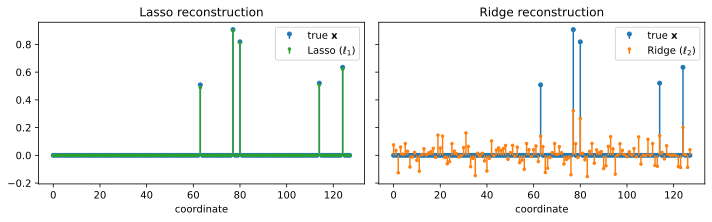

pinv  rel. error = 0.823
ridge rel. error = 0.823
lasso rel. error = 0.018  (alpha = 0.01)


In [4]:
#| label: fig-l1-recovery
#| cap: "**L1 recovers the support, L2 does not.** The true signal with the Lasso reconstruction ($\\ell_1$, left) and the Ridge reconstruction ($\\ell_2$, right) on the same measurements. The Lasso concentrates on the five true coordinates; the Ridge solution is dense, just like the minimum-norm solution."
from sklearn.linear_model import Lasso, Ridge

alphas = [1e-3, 1e-2, 1e-1, 1.0, 10.0]
print('Lasso, tuning alpha:')
print(f'{"alpha":>8} {"rel. error":>10} {"# nonzero":>9} {"support ok":>10}')
for alpha in alphas:
    lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=20000).fit(A, b)   # <1>
    x_l1 = lasso.coef_
    supp = np.abs(x_l1) > 1e-4
    ok = np.array_equal(np.sort(np.nonzero(x)[0]), np.sort(np.nonzero(supp)[0]))
    err = np.linalg.norm(x - x_l1) / np.linalg.norm(x)
    print(f'{alpha:8.1e} {err:10.4f} {np.count_nonzero(supp):9d} {str(ok):>10}')

alpha_l1 = 1e-2
x_l1 = Lasso(alpha=alpha_l1, fit_intercept=False, max_iter=20000).fit(A, b).coef_

x_l2 = Ridge(alpha=1e-1, fit_intercept=False).fit(A, b).coef_                    # <2>

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for a, xh, lab, col in [
    (ax[0], x_l1, 'Lasso ($\\ell_1$)', 'C2'),
    (ax[1], x_l2, 'Ridge ($\\ell_2$)', 'C1'),
]:
    s = a.stem(x, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='true $\\mathbf{x}$')
    s.markerline.set_markersize(4)
    s = a.stem(xh, linefmt=col + '-', markerfmt=col + 'o', basefmt=' ', label=lab)
    s.markerline.set_markersize(2.5)
    a.set_xlabel('coordinate')
    a.legend()
ax[0].set_title('Lasso reconstruction')
ax[1].set_title('Ridge reconstruction')
fig.tight_layout()
plt.show()

err_l1 = np.linalg.norm(x - x_l1) / np.linalg.norm(x)
err_l2 = np.linalg.norm(x - x_l2) / np.linalg.norm(x)
print(f'pinv  rel. error = {err_pinv:.3f}')
print(f'ridge rel. error = {err_l2:.3f}')
print(f'lasso rel. error = {err_l1:.3f}  (alpha = {alpha_l1})')


**L1 recovers the support, L2 does not.** The annotations: `<1>` fits the Lasso by coordinate descent with no intercept — the model is exactly $\mathbf{b} = \mathbf{A}\mathbf{x}$; `<2>` fits the Ridge by a direct linear solve, the same ridge regression as Chapter 10. Three observations.

First, the tuning table: for `alpha` between $10^{-3}$ and $10^{-1}$ the Lasso finds exactly the five true coordinates — the column "support ok" reads `True` — and the error shrinks as `alpha` shrinks ($1.9\%$ at $\alpha = 10^{-2}$). A too-large penalty ($\alpha = 1$) forces the whole vector to zero, with only the largest coefficient surviving; that is the shrinkage bias of $\ell_1$, not a failure of the geometry.

Second, the left stem plot: the Lasso reconstruction sits on the true support with nearly exact values. The right stem plot: Ridge is dense, with small mass on every coordinate, and its error of 0.82 matches the minimum-norm solution. This is forced: $\hat{\mathbf{x}}_{\text{ridge}} = (\mathbf{A}^{\mathsf T}\mathbf{A} + \alpha\mathbf{I})^{-1}\mathbf{A}^{\mathsf T}\mathbf{b} \to \mathbf{A}^{+}\mathbf{b}$ as $\alpha \to 0$, so no choice of `alpha` can make Ridge sparse. The two penalties solve two different problems, and the data are generated by the one the $\ell_1$ penalty encodes.


## How many measurements? The restricted isometry property

The experiment raises a quantitative question: for which pairs $(m, K)$ does $\ell_1$ recovery work? The answer is a property of the measurement matrix, the [restricted isometry property]{.mark} (RIP): $\mathbf{A}$ acts like an isometry on the set of $K$-sparse vectors. Concretely, $\mathbf{A}$ has RIP constant $\delta_K$ if

$$
(1 - \delta_K)\lVert\mathbf{x}\rVert_2^2 \le \lVert\mathbf{A}\mathbf{x}\rVert_2^2 \le (1 + \delta_K)\lVert\mathbf{x}\rVert_2^2
\qquad \text{for every } K\text{-sparse } \mathbf{x}.
$$

If $\delta_{2K}$ is small — the standard sufficient condition is $\delta_{2K} < \sqrt{2} - 1$ — then the minimum-$\ell_1$ solution of $\mathbf{A}\mathbf{x} = \mathbf{b}$ recovers every $K$-sparse signal exactly. The intuition: a small $\delta_{2K}$ means no $K$-sparse vector lies near the null space of $\mathbf{A}$, so the measurements separate all $K$-sparse candidates, and the $\ell_1$ minimizer is the sparsest one consistent with $\mathbf{b}$. The proof is a convexity argument comparing the $\ell_1$ and $\ell_2$ norms on $2K$-sparse vectors, not reproduced here.[^rip]

The RIP is a property of random matrices. A Gaussian $\mathbf{A}$ with

$$
\boxed{\ m \gtrsim K\log(n/K)\ }
$$

rows satisfies the RIP with $\delta_{2K} < \sqrt{2} - 1$ with high probability, and the constant hidden in $\gtrsim$ is an absolute constant independent of $n$ and $K$.[^rip] The logarithmic factor is the price of not knowing the support in advance: choosing $K$ of $n$ coordinates is a combinatorial decision carrying about $\log\binom{n}{K} \approx K\log(n/K)$ bits of information, and each measurement must contribute a comparable amount. The warm-up is consistent with the bound: $K\log(n/K) = 5\log(128/5) \approx 16$, and $m = 40$ measurements sufficed comfortably.

The same convexity that guarantees a global minimizer (Chapter 10) guarantees tractability: the $\ell_1$ objective is convex, so recovery is a convex optimization problem solvable by simple first-order iterations, with no combinatorial search over supports.

[^rip]: Precise statement: a Gaussian $\mathbf{A}\in\mathbb{R}^{m\times n}$ satisfies the RIP with constant $\delta_{2K}$ with probability $1 - e^{-ct}$ once $m \ge CK\log(n/K) + t$. The exact-recovery guarantee is due to Candès, Romberg, and Tao (2006) and, independently, Donoho (2006); see the Wikipedia article on the [restricted isometry property](https://en.wikipedia.org/wiki/Restricted_isometry_property).


## A CT-style phantom

The one-dimensional experiment transfers directly to imaging. **The model.** The ground truth is a $48\times 48$ image of six bright disks on a black canvas — a sparse image in the pixel basis, in the spirit of the [Shepp–Logan phantom](https://en.wikipedia.org/wiki/Shepp%E2%80%93Logan_phantom) used to benchmark tomography algorithms. The next cell draws it.

**The measurements.** An X-ray projection at angle $\theta$ is the set of line integrals of the image along parallel rays: rotate the image by $\theta$ and sum along the rows. Each projection contributes 48 measurements (one per row), and a measurement matrix $\mathbf{A}$ carries one row per ray. With 16 angles at $15^\circ$ spacing the system has $m = 16 \times 48 = 768$ rows and $n = 2304$ columns: about a third of the pixels are "measured", yet the image is only about 9% nonzero, so the RIP heuristic of the previous section says recovery is feasible.


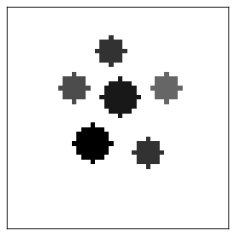

image: 48 x 48 = 2304 pixels,  214 nonzero (9.3%)


In [5]:
#| label: fig-phantom
#| cap: "**Ground-truth phantom.** Six filled disks of different intensities on a $48\\times 48$ black canvas. The image is sparse in the pixel basis: 214 of 2304 pixels are nonzero."
side = 48
yy, xx = np.mgrid[0:side, 0:side].astype(float)

def disk(cx, cy, r, v):
    """Filled disk: intensity v, radius r, center (cx, cy)."""
    return v * ((xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2)

x_2d = np.zeros((side, side))
for (cx, cy, r, v) in [(18, 18, 4, 1.0), (30, 16, 3, 0.8), (24, 28, 4, 0.9),
                       (14, 30, 3, 0.7), (34, 30, 3, 0.6), (22, 38, 3, 0.8)]:
    x_2d += disk(cx, cy, r, v)
x_2d = np.clip(x_2d, 0.0, 1.0)

K2 = np.count_nonzero(x_2d)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(x_2d, cmap='gray_r', origin='lower')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

print(f'image: {side} x {side} = {side * side} pixels,'
      f'  {K2} nonzero ({100 * K2 / side ** 2:.1f}%)')


**The measurement operator.** One projection: rotate the image by $\theta$ and sum the rows with `scipy.ndimage.rotate` (bilinear interpolation, same canvas), then `sum(axis=1)`. The matrix $\mathbf{A}$ applies this operator to every pixel: column $j$ of $\mathbf{A}$ is the projection of the $j$-th basis image (a single pixel of value 1). Rather than rotating 2304 images one by one, the cell stacks them into one array of shape $(2304, 48, 48)$ and rotates the stack once per angle — `ndimage.rotate` with `axes=(1, 2)` rotates every plane independently, so the planes never mix.


In [6]:
import scipy.ndimage as ndi

angles = np.linspace(0, 165, 16)                                 # <1>
n_angles = len(angles)
n_pix = side * side
m = n_angles * side

basis = np.zeros((n_pix, side, side))                            # <2>
idx = np.arange(n_pix)
basis[idx, idx // side, idx % side] = 1.0

A_2d = np.empty((m, n_pix))
for k, theta in enumerate(angles):
    rot = ndi.rotate(basis, theta, axes=(1, 2), reshape=False, order=1)   # <3>
    A_2d[k * side:(k + 1) * side] = rot.sum(axis=1).T            # <4>

b_2d = A_2d @ x_2d.ravel()
print(f'A: {m} x {n_pix},  sampling ratio m/n = {m / n_pix:.2f}')


A: 768 x 2304,  sampling ratio m/n = 0.33


**The matrix.** The annotations: `<1>` the 16 projection angles, $0^\circ$ to $165^\circ$ in steps of $15^\circ$; `<2>` the stack of basis images, one per pixel; `<3>` rotates every plane of the stack by the same angle in a single call; `<4>` sums the rows of each rotated basis image and writes the result into the block of $\mathbf{A}$ for angle $k$.

The resulting operator is $768 \times 2304$: the measurements $\mathbf{b} = \mathbf{A}\mathbf{x}$ use a third of the pixel count. The phantom has $K = 214$ nonzero pixels, and the heuristic of the previous section gives $K\log(n/K) = 214\log(2304/214) \approx 508 < 768$: the measurement budget is sufficient, with room to spare. The next cell runs both recovery rules on the same $\mathbf{b}$.


## Reconstruction: L2 smears, L1 concentrates

**The comparison.** Both solvers see the same measurements $\mathbf{b}$. Ridge at `alpha = 1e-1` represents the $\ell_2$ route — its error is flat across a wide range of `alpha`, since the ridge solution is pinned to the minimum-norm solution; Lasso at `alpha = 1e-3` represents the $\ell_1$ route, chosen from the same small grid used for the one-dimensional experiment. The figure below shows the phantom, the Ridge reconstruction, and the Lasso reconstruction; the printed errors are relative residuals $\lVert\mathbf{x} - \hat{\mathbf{x}}\rVert_2 / \lVert\mathbf{x}\rVert_2$.


relative errors ||x - x_hat|| / ||x||:


  Lasso  alpha= 1.0e-03  0.0438


  Lasso  alpha= 1.0e-02  0.3991
  Lasso  alpha= 1.0e-01  0.7959
  Ridge  alpha= 1.0e-01  0.3391
  Ridge  alpha= 1.0e+00  0.3421
  Ridge  alpha= 1.0e+01  0.3723


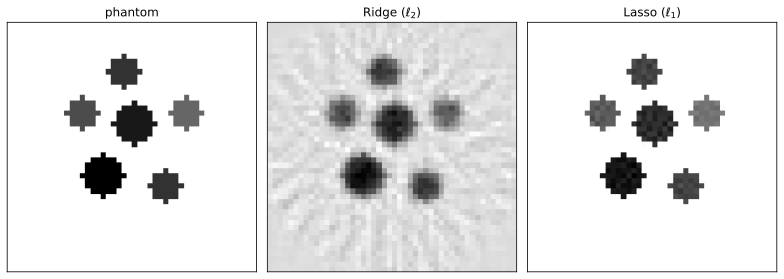

ridge rel. error = 0.339
lasso rel. error = 0.044


In [7]:
#| label: fig-ct-recon
#| cap: "**Tomographic reconstruction from 768 projections.** The phantom, the Ridge reconstruction ($\\ell_2$), and the Lasso reconstruction ($\\ell_1$). Ridge smears each disk into a faint halo; Lasso recovers the six disks at the correct positions with the correct intensities."
from sklearn.linear_model import Ridge, Lasso

print('relative errors ||x - x_hat|| / ||x||:')
for alpha in [1e-3, 1e-2, 1e-1]:
    x_l = Lasso(alpha=alpha, fit_intercept=False, max_iter=20000).fit(A_2d, b_2d).coef_
    print(f'  Lasso  alpha={alpha:8.1e}  {np.linalg.norm(x_2d.ravel() - x_l) / np.linalg.norm(x_2d):.4f}')
for alpha in [1e-1, 1.0, 10.0]:
    x_r = Ridge(alpha=alpha, fit_intercept=False).fit(A_2d, b_2d).coef_
    print(f'  Ridge  alpha={alpha:8.1e}  {np.linalg.norm(x_2d.ravel() - x_r) / np.linalg.norm(x_2d):.4f}')

x_ridge = Ridge(alpha=1e-1, fit_intercept=False).fit(A_2d, b_2d).coef_.reshape(side, side)  # <1>
x_lasso = Lasso(alpha=1e-3, fit_intercept=False, max_iter=20000).fit(A_2d, b_2d).coef_.reshape(side, side)  # <2>

fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
for a, im, t in zip(ax, [x_2d, x_ridge, x_lasso],
                    ['phantom', 'Ridge ($\\ell_2$)', 'Lasso ($\\ell_1$)']):
    a.imshow(im, cmap='gray_r', origin='lower')
    a.set_title(t)
    a.set_xticks([])
    a.set_yticks([])
fig.tight_layout()
plt.show()

err_r = np.linalg.norm(x_2d.ravel() - x_ridge.ravel()) / np.linalg.norm(x_2d)
err_l = np.linalg.norm(x_2d.ravel() - x_lasso.ravel()) / np.linalg.norm(x_2d)
print(f'ridge rel. error = {err_r:.3f}')
print(f'lasso rel. error = {err_l:.3f}')


**L2 smears, L1 concentrates.** The annotations: `<1>` the Ridge reconstruction, `<2>` the Lasso reconstruction at the tuned `alpha`. Two observations.

First, Ridge fails in exactly the way the one-dimensional experiment predicted. Its solution is dense — every pixel carries some faint intensity — so each disk appears as a soft halo spread over the whole canvas, and the relative error is 0.34. The image content is "explained" by energy that is everywhere, which is the $\ell_2$ ball doing what its geometry forces. Second, Lasso recovers the phantom structure: the six disks reappear at the right positions with the right intensities, at a relative error of 0.04, with mild speckle artifacts and slightly shrunken intensities — the $\ell_1$ bias seen in the tuning table.

The solver is worth a closing remark. Coordinate descent, the algorithm behind `Lasso`, is linear algebra under the hood: each step is a matrix-vector product with $\mathbf{A}$ and $\mathbf{A}^{\mathsf T}$, plus one nonlinear entrywise step — the soft-thresholding operator of Chapter 13. The nonlinearity is exactly where sparsity enters; everything else is the machinery of Chapters 3, 6, and 8.


## L1 versus L2 at a glance

| | $\ell_1$ (Lasso, basis pursuit) | $\ell_2$ (Ridge, min-norm) |
|---|---|---|
| Penalty | $\alpha\lVert\mathbf{x}\rVert_1$ | $\alpha\lVert\mathbf{x}\rVert_2^2$ |
| Penalty ball | corners on the coordinate axes | round, no corners |
| Typical solution | few nonzero entries | all entries nonzero |
| Underdetermined systems | recovers a sparse support | spreads energy, dense |
| Failure mode | bias and support instability under heavy noise | misses sparsity entirely |
| Right when | signal genuinely sparse, $m \ll n$ | dense signal, $m \ge n$ |

::: {.callout-note}
**The measurement budget.** The working heuristic for sparse recovery: $m \gtrsim K\log(n/K)$, where $K$ is the number of nonzero entries of $\mathbf{x}$. The precise guarantee (Candès–Romberg–Tao 2006; Donoho 2006) is that a random Gaussian $\mathbf{A}$ with $m \ge CK\log(n/K)$ rows satisfies the [restricted isometry property](https://en.wikipedia.org/wiki/Restricted_isometry_property) with high probability, and that the minimum-$\ell_1$ solution then recovers every $K$-sparse signal exactly — stably, in the presence of noise. In practice the constant $C$ is a small number (roughly 2–4), so the heuristic is a genuine guide, not just an asymptotic statement.

The applications are wherever acquisition is the bottleneck: computed tomography with fewer projections (less radiation), MRI with fewer k-space samples (shorter scans), radar, astronomy, and sensor networks. In each case the hardware measures linear combinations of the signal; compressed sensing says the recovery algorithm — not the scanner — decides how many are needed. See the Wikipedia articles on [compressed sensing](https://en.wikipedia.org/wiki/Compressed_sensing), [basis pursuit](https://en.wikipedia.org/wiki/Basis_pursuit), and the [Lasso](https://en.wikipedia.org/wiki/Lasso_(statistics)).
:::


## Summary

- **Underdetermined plus sparse means $\ell_1$.** The minimum-norm solution $\mathbf{A}^{+}\mathbf{b}$ minimizes energy, not sparsity, and on a 5-sparse signal in $\mathbb{R}^{128}$ its relative error is $\sqrt{1 - m/n} = 0.83$: the reconstruction is dense because a random row space aligns with no coordinate. The Lasso with $\alpha = 10^{-2}$ recovers the support exactly, at $1.9\%$ error.
- **The geometry decides.** The $\ell_1$ ball has corners on the coordinate axes, so the smallest ball touching the feasible set touches at a corner — a sparse point. The $\ell_2$ ball is round, so its touching point is dense. The same geometry reappears in two dimensions: Ridge smears the phantom (34% error), Lasso recovers it (4% error).
- **The count.** A Gaussian measurement matrix satisfies the restricted isometry property with high probability once $m \gtrsim K\log(n/K)$; under the RIP the $\ell_1$ minimizer recovers every $K$-sparse signal exactly, and convexity (Chapter 10) keeps the search tractable.

This closes the applications arc of the course: Chapter 11 put the SVD/NMF decomposition to work on topic modeling, Chapter 12 the eigenvector machinery on PageRank, Chapter 13 the low-rank-plus-sparse decomposition on robust PCA, and this chapter the sparse-recovery geometry on compressed sensing. Four problems, one arc: each is a decomposition or optimization idea from the first ten chapters, applied where the data are large and the structure is small.
